In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/featured.csv')
print(f"✅ Loaded! {df.shape[0]} rows × {df.shape[1]} columns")

✅ Loaded! 19548 rows × 41 columns


In [2]:
# These are the features our model will learn from
features = [
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Valence',
    'Tempo', 'duration_min', 'engagement_ratio',
    'energy_dance', 'positivity_score',
    'artist_platform_score', 'album_type_encoded'
]

# Target is platform_label (0=YouTube, 1=Cross-platform, 2=Spotify)
X = df[features]
y = df['platform_label']

print(f"✅ Features shape : {X.shape}")
print(f"✅ Target shape   : {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

✅ Features shape : (19548, 15)
✅ Target shape   : (19548,)

Class distribution:
platform_label
2    6646
0    6451
1    6451
Name: count, dtype: int64


In [3]:
# 80% training data, 20% testing data
# random_state=42 means results are reproducible every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set : {X_train.shape[0]} rows")
print(f"✅ Testing set  : {X_test.shape[0]} rows")

✅ Training set : 15638 rows
✅ Testing set  : 3910 rows


In [4]:
# Random Forest builds many decision trees and combines their results
rf_model = RandomForestClassifier(
    n_estimators=100,   # 100 trees
    max_depth=10,       # each tree goes 10 levels deep
    random_state=42
)

rf_model.fit(X_train, y_train)  # train the model

rf_preds = rf_model.predict(X_test)  # predict on test data

print("✅ Random Forest trained!")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds,
      target_names=['YouTube-native','Cross-platform','Spotify-native']))

✅ Random Forest trained!

Classification Report:
                precision    recall  f1-score   support

YouTube-native       0.69      0.72      0.71      1290
Cross-platform       0.55      0.49      0.52      1290
Spotify-native       0.70      0.75      0.72      1330

      accuracy                           0.65      3910
     macro avg       0.65      0.65      0.65      3910
  weighted avg       0.65      0.65      0.65      3910



In [5]:
# XGBoost builds trees one by one, each one fixing errors of the previous
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("✅ XGBoost trained!")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['YouTube-native','Cross-platform','Spotify-native']))

✅ XGBoost trained!

Classification Report:
                precision    recall  f1-score   support

YouTube-native       0.70      0.72      0.71      1290
Cross-platform       0.54      0.51      0.53      1290
Spotify-native       0.70      0.72      0.71      1330

      accuracy                           0.65      3910
     macro avg       0.65      0.65      0.65      3910
  weighted avg       0.65      0.65      0.65      3910



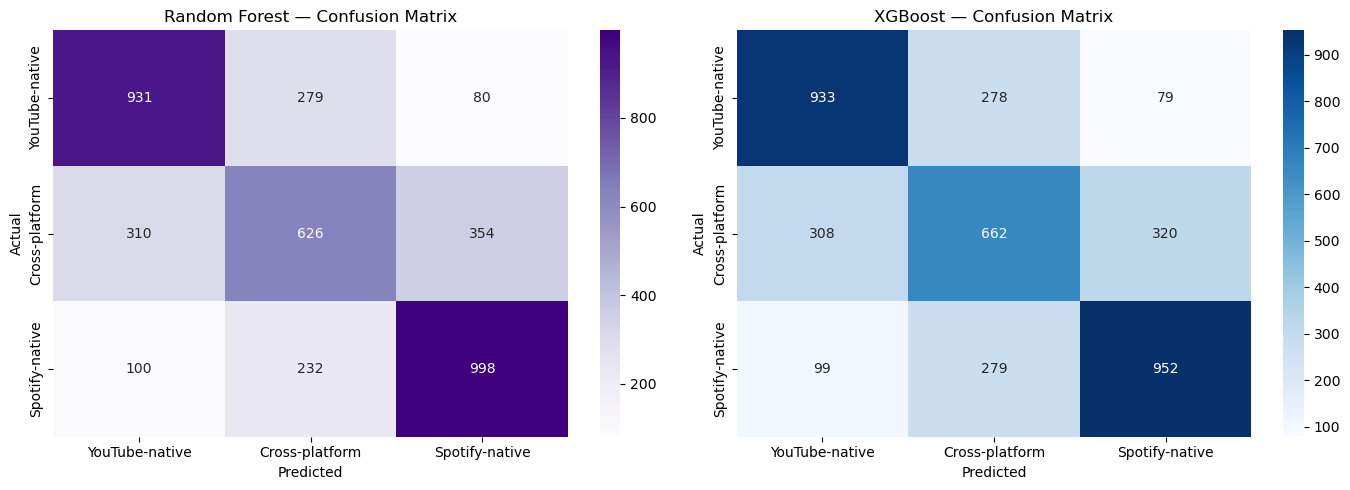

✅ Saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ['YouTube-native', 'Cross-platform', 'Spotify-native']

# Random Forest confusion matrix
sns.heatmap(confusion_matrix(y_test, rf_preds),
            annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# XGBoost confusion matrix
sns.heatmap(confusion_matrix(y_test, xgb_preds),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('XGBoost — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/figures/classification_confusion_matrix.png')
plt.show()
print("✅ Saved!")

In [7]:
import pickle

# Save both models so we don't retrain every time
with open('../models/rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/xgb_classifier.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ Models saved to models/ folder!")

✅ Models saved to models/ folder!
